<a href="https://colab.research.google.com/github/Avyayyy/dog-breed-identification/blob/main/dog_breed_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# End-to-End Multi-class Dog breed Classification

This notebook builds an end-to-end multi-class image classifier using TensorFlow and TensorFlow Hub.

The workflow I'll be following:
1. Problem
2. Data
3. Evaluation
4. Features
5. Modelling
6. Experimentation

## 1. Problem

Identifiying the breed of a dog given an image of a dog.

## 2. Data

The Data I'm using is from Kaggle's Dog Breed Identification Competition - https://www.kaggle.com/competitions/dog-breed-identification/data

## 3. Evaluation

The evaluation mentioned on Kaggle is a file with prediction probabilites for each dog breed for each image - www.kaggle.com/competitions/dog-breed-identification/overview/evaluation

## 4. Features

Some information about the data:
* Dealing with images of dogs (Unstructured Data), so we need to use Deep Learning / Transfer Learning
* The dataset comprises 120 breeds of dogs (Multi-Class Classification --> 120 classes)
* There are 10,000+ images in the training set (with labels)
* There are 10,000+ images in the test set (without labels)

File descriptions:
* train.zip - the training set, you are provided the breed for these dogs
* test.zip - the test set, you must predict the probability of each breed for each image
* sample_submission.csv - a sample submission file in the correct format
* labels.csv - the breeds for the images in the train set

In [1]:
# Unzip the uploaded data into Google Drive
#!unzip "/content/drive/MyDrive/Dog Vision/dog-breed-identification.zip" -d "/content/drive/MyDrive/Dog Vision"

### Get our workspace ready

* Import TensorFlow
* Import TensorFlow Hub
* Make sure we're using a GPU

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
print("TF version:", tf.__version__)
print("TF Hub version", hub.__version__)

# Check for GPU availability
print("GPU", "available" if tf.config.list_physical_devices("GPU") else "not available")

TF version: 2.20.0
TF Hub version 0.16.1
GPU available


## Getting our data ready (turning into Tensors)

Let's start by accessing the data and checking out the labels.

In [3]:
# Checkout the labels of our data
import pandas as pd
labels_csv = pd.read_csv("/content/drive/MyDrive/Dog Breed Identification/labels.csv")
labels_csv.describe()

,id,breed
count,10222,10222
unique,10222,120
top,fff43b07992508bc822f33d8ffd902ae,scottish_deerhound
freq,1,126


In [4]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [5]:
# How many images are there of each breed?
labels_csv["breed"].value_counts()

,count
breed,
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114
...,...
golden_retriever,67
komondor,67
brabancon_griffon,67


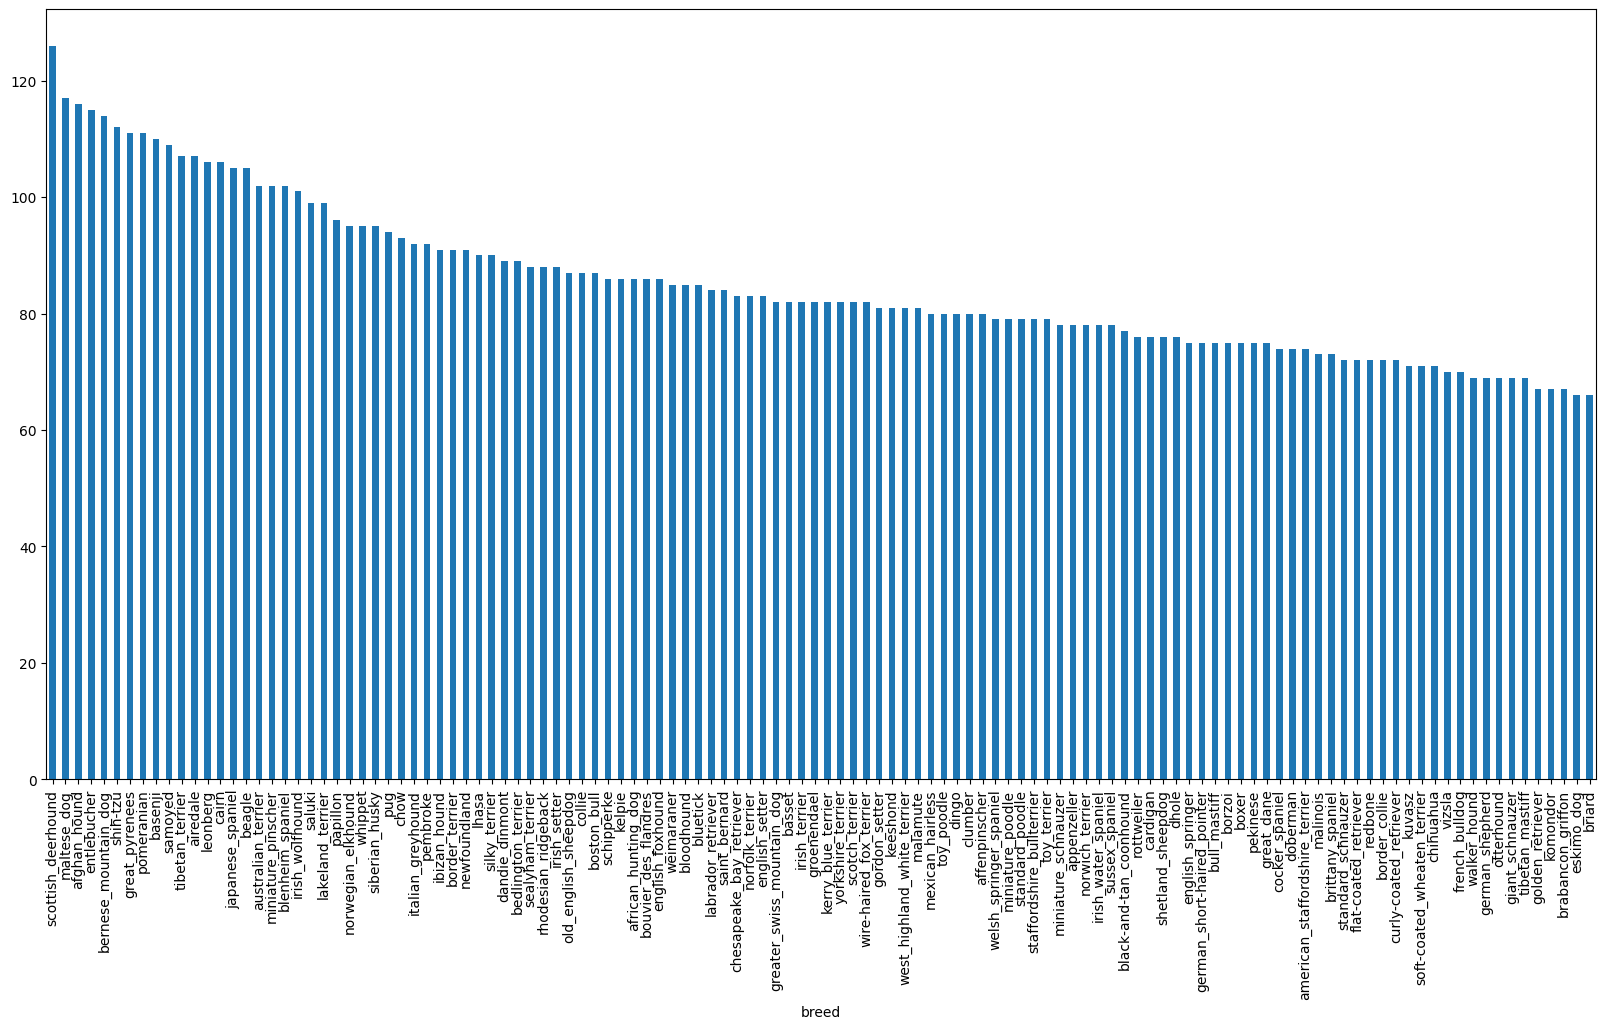

In [6]:
# Let's visualise this
labels_csv["breed"].value_counts().plot.bar(figsize=(20, 10));

In [7]:
labels_csv["breed"].value_counts().median()

82.0

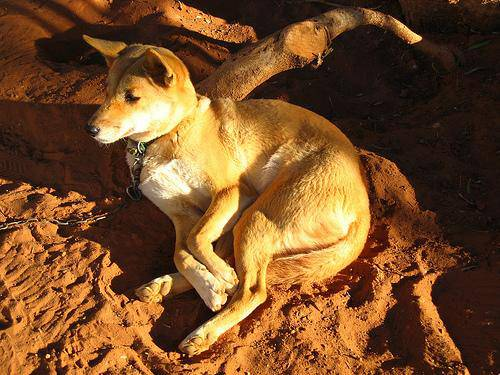

In [8]:
# Let's view an image
from IPython.display import Image
Image("/content/drive/MyDrive/Dog Breed Identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg")

### Getting images and their labels

Let's get a list of all of our image file pathnames

In [9]:
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [10]:
# Create pathnames from image ID's using List Comprehension
pathnames = ["/content/drive/MyDrive/Dog Breed Identification/train/" + fname + ".jpg" for fname in labels_csv["id"]]
pathnames[:10]

['/content/drive/MyDrive/Dog Breed Identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/002211c81b498ef88e1b40b9abf84e1d.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/00290d3e1fdd27226ba27a8ce248ce85.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/002a283a315af96eaea0e28e7163b21b.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/003df8b8a8b05244b1d920bb6cf451f9.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/0042188c895a2f14ef64a918ed9c7b64.jpg']

In [11]:
''' Check whether number of pathnames we got from 'labels.csv'
matches the number of actual image files in 'train' folder '''

import os
if len(os.listdir("/content/drive/MyDrive/Dog Breed Identification/train")) == len(pathnames):
  print("Same number of files")
else:
  print("Different number of file")

Same number of files


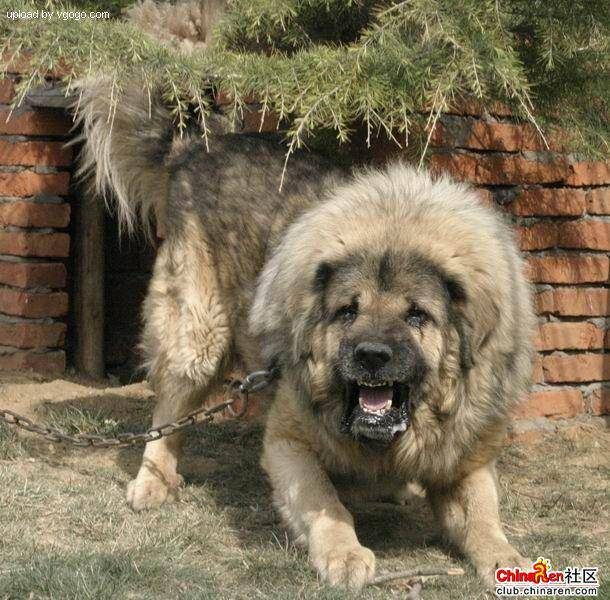

In [12]:
Image(pathnames[9000]) # From Ipython.display module

#### Since we've know got our training image file paths in a list (pathnames), let's prepare our labels which we need to match with the pathnames and eventually convert to numbers.

In [13]:
import numpy as np
labels = labels_csv["breed"]
labels = np.array(labels)
labels

array(['boston_bull', 'dingo', 'pekinese', ..., 'airedale',
       'miniature_pinscher', 'chesapeake_bay_retriever'], dtype=object)

In [14]:
len(labels)

10222

In [15]:
# Check whether number of labels matches the number of pathnames (check for missing data)
if len(pathnames) == len(labels):
  print("Same number of labels and pathnames")
else:
  print("Different number of labels and pathnames")

Same number of labels and pathnames


In [16]:
type(labels) # labels is a NumPy array of strings which we need to convert to numbers

numpy.ndarray

In [17]:
# Find the unique label values
unique_breeds = np.unique(labels)
unique_breeds

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [18]:
# Check if we have 120 unique dog breeds as said in the Data Description for this kaggle dataset
len(unique_breeds)

120

In [19]:
# Turn every label into a boolean array using list comprehension
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [20]:
len(boolean_labels)

10222

In [21]:
print(boolean_labels[0].astype("int"))

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


### Creating our own Validation set

Since the dataset from Kaggle only has Train and Test sets, need to create a Validation set to the test the model first before the Test set.

* Train the ML model on the `Training Set`
* Evaluate the ML model on the `Validation Set`
* Test the ML model on the `Test Set`

In [22]:
# Create X (features) and y (labels)
X = pathnames
y = boolean_labels

In [23]:
len(X)

10222

In [24]:
X[:5]

['/content/drive/MyDrive/Dog Breed Identification/train/000bec180eb18c7604dcecc8fe0dba07.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/001513dfcb2ffafc82cccf4d8bbaba97.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/001cdf01b096e06d78e9e5112d419397.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/00214f311d5d2247d5dfe4fe24b2303d.jpg',
 '/content/drive/MyDrive/Dog Breed Identification/train/0021f9ceb3235effd7fcde7f7538ed62.jpg']

In [25]:
len(y)

10222

In [26]:
y[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

We're going to start off experimenting with ~1000 images and increase as needed

In [27]:
# Set number of images to use for experimenting using slider feature in colab
NUM_IMAGES = 1000 #@param {type: "slider", min: 1000, max:10000, step:1000}

In [28]:
# Set Random Seed
np.random.seed(42)

# Split data into train and validation sets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X[:NUM_IMAGES],
                                                  y[:NUM_IMAGES],
                                                  test_size = 0.2)

len(X_train), len(X_val), len(y_train), len(y_val)

(800, 200, 800, 200)

In [29]:
X_train[:2], y_train[:2]

(['/content/drive/MyDrive/Dog Breed Identification/train/00bee065dcec471f26394855c5c2f3de.jpg',
  '/content/drive/MyDrive/Dog Breed Identification/train/0d2f9e12a2611d911d91a339074c8154.jpg'],
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False,

## Preprocessing Images (turning images into Tensors)

Create a function which does the following:
1. Take an image `pathname` as input
2. Use TensorFlow to read the file and save it to a variable `image`
3. Turn our `image` into `Tensors`
4. Normalize our image (convert color channel values from 0-255 to 0-1)
5. Resize the `image` to be a shape of (224, 224)
6. Return the modified `image`

In [30]:
# Define image size
IMG_SIZE = 224

# Create a function for preprocessing images
def preprocess_image(image_path):
  """
  Takes an image pathname and turns the image into a Tensor.
  """
  # Read in an image file
  image = tf.io.read_file(image_path)

  # Turn the image into a tensor with 3 colour channels (Red, Green, Blue)
  image = tf.image.decode_jpeg(image, channels = 3)

  # Convert the colour channel values from 0-255 to 0-1 values
  image = tf.image.convert_image_dtype(image, tf.float32)

  # Resize the image to our desired value (224, 224)
  image = tf.image.resize(image, size = [IMG_SIZE, IMG_SIZE])

  return image

## Turning Data into Data Batches

In [31]:
# Create a simple function to return a tuple (image, label)
def get_image_label(image_path, label):
  """
  Takes an image file path name and the associated label,
  processes the image and returns a tuple of (image, label).
  """
  image = preprocess_image(image_path)
  return image, label

In [37]:
# Define batch size
BATCH_SIZE = 32

# Create a function to turn data into batches
def create_data_batches(X, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
  """
  Creates batches of data out of image (X) and label (y) pairs.
  Shuffles the data if it's training data but doesn't shuffle it if it's validation data.
  Also accepts test data as input (no labels).
  """
  # If Test Dataset, we don't have labels
  if test_data:
    print("Creating test data batches")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X))) # only filepaths, no labels
    data_batch = data.map(preprocess_image).batch(BATCH_SIZE)
    return data_batch

  # If Validation Dataset, we don't need to shuffle it
  elif valid_data:
    print("Creating validation data batches")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),
                                              tf.constant(y)))
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch

  # If Training Dataset, we want to shuffle it
  else:
    print("Creating training data batches")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(X),
                                              tf.constant(y)))
    data = data.shuffle(buffer_size = len(X))
    data_batch = data.map(get_image_label).batch(BATCH_SIZE)
    return data_batch

In [38]:
# Create Training and Validation Data Batches
train_data = create_data_batches(X_train, y_train)
val_data = create_data_batches(X_val, y_val, valid_data=True)

Creating training data batches
Creating validation data batches


In [39]:
train_data.element_spec, val_data.element_spec

((TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)),
 (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None),
  TensorSpec(shape=(None, 120), dtype=tf.bool, name=None)))

## Visualizing Data Batches

In [41]:
import matplotlib.pyplot as plt

# Create a function for viewing images in a Data Batch
def show_10_images(images, labels):
  """
  Displays a plot of 10 images and their labels from the Data Batch
  """
  plt.figure(figsize = (10, 10))
  for i in range(10):
    ax = plt.subplot(2, 5, i+1)
    plt.imshow(images[i])
    # plt.axis("off")
    plt.title(unique_breeds[labels[i].argmax()])

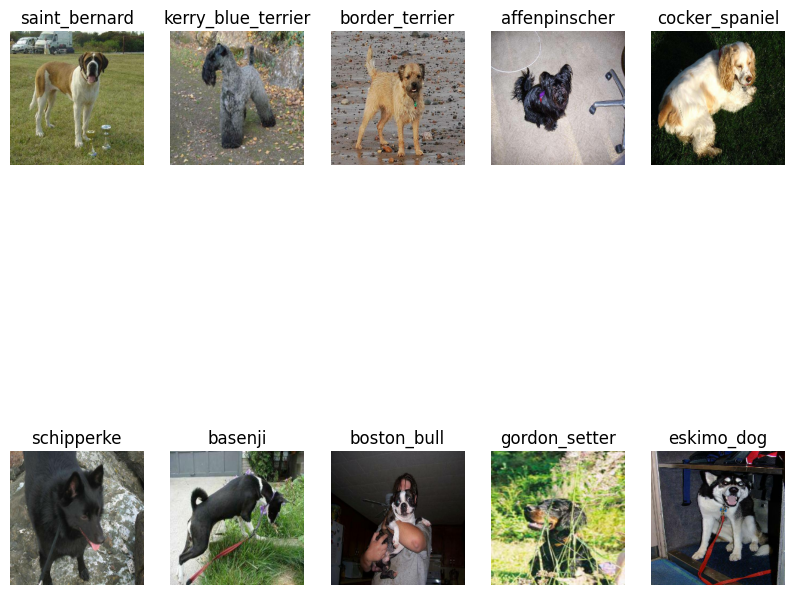

In [43]:
train_images, train_labels = next(train_data.as_numpy_iterator())
show_10_images(train_images, train_labels)